## IIP314W Optimización aplicada a negocios

La optimización es importante en ciencias de datos, pues sus técnicas y algoritmos pueden ser aplicados al machine learning e inteligencia artificial, requiere una buena base matemática y también pueden ser aplicados en otras áreas de la ingeniería como los negocios. Ya vimos algo en curso metodos numéricos, que revisaremos a modo de introducción.

Preliminarmente, la forma de evaluación será:
- Certamenes (30-40%)
- Tareas-Ejercicios (30%)
- Examen (30%)

### Introducción - Optimización clásica

Definición **Optimizar**. Aparece en todo momento en nuestra vida, cada vez que debemos tomar una decisión probablemente optimicemos algo. Algunos ejemplos:

- Mejor ruta para llegar a la universidad, transporte publico, auto, a pie, etc. Regularmente buscamos reducir el tiempo de viaje, aunque podríamos buscar otros objetivos.
- Compra de **café**: Elección de sabor de cafe, tamaño, tienda o local de compra. Habrá restricciones a la compra?.
- Elección carrera y universidad a estudiar. Ponderamos intereses, nuestras habilidades, necesidades del mercado laboral?.
- Cuanto tiempo debo estudiar para el certamen de este curso?

Todos estos problemas comparten lo siguiente:

- Tenemos un **Espacio de Decisión**, el cual es finito para que podamos evaluar y decidir. Aunque a veces puede ser infinito, podemos descartar facilmente algunas opciones por factibilidad. En el ejemplo ruta para llegar a la universidad, existe la opción de ir al aeropuerto, viajar a Concepción, tomar un bus regional, bajar en el terminal y tomar un Uber que nos traiga desde alla.
- Podemos definir una función que mida o evalue las opciones, que tenga un compromiso entre los costos y recompensas de la decisión, la cual normalmente denominados **función objetivo**, que normalmente maximizamos o minimizamos.
- Regularmente, usamos un **metodo de solución**, la cual nos apoya en la solución. Ejemplo: Abrir gooogle maps y preguntarle por rutas a la universidad.

En el **espacio de decisión**, podemos contar con variables de decisión discretas finitas o continuas, por ejemplo todos los recorridos del transporte son finito, en cambio el tiempo de estudio, es continuo y restringido, ya que no puede ser negativo.

La **función objetivo** la debemos definir de manera sencilla y que represente o modele un proceso, pensemos en el tiempo que debemos gastar para estudiar para el certamen de optimización. ¿cómo debiese ser es función f(t)?, ¿parabola invertida?, ¿que representa f?, ¿tiempo excesivo podría ser contraproducente?. 

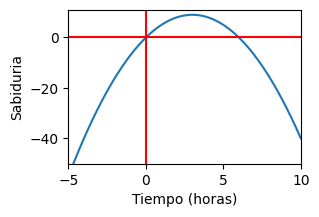

In [1]:
# ejemplo parabola invertida, pasa por (0,0)
import numpy as np
import matplotlib.pyplot as plt

f_obj = lambda t: -t**2 + 6*t
t = np.linspace(-5, 10)
plt.figure(figsize=(3,2))
plt.plot(t, f_obj(t))
plt.plot([-5,10], [0,0], color="red")
plt.plot([0,0], [-50,11], color="red")
plt.xlim(-5,10)
plt.ylim(-50,11)
plt.xlabel("Tiempo (horas)")
plt.ylabel("Sabiduria")
plt.show()

- Definamos el espacio de decisión, existe tiempo de estudio negativo, nivel de conocimiento o sabiduria negativa.

Si esa fuese nuestra función objetivo, nuestro problema de optimización seria maximizar la sabiduría (si es que eso existe) y el espacio decisión factible o "razonable", sería entre las raices de la función. En metodos numéricos, vimos metodos iterativos como bisección para encontrar las raices. La solución seria:

$$ t^{*} = arg \space max \space f(t)$$

Tipicamente, en curso de cálculo para encontrar la solución derivamos la función e igualamos a 0.

$$ \frac{df}{dt} = -2t + 6 == 0 $$

Si igualamos a 0, entonces $t^{*} = 3$, si acoto el espacio de decisión y grafico ambas funciones tengo:

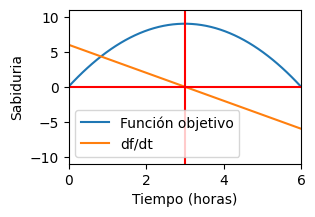

In [2]:
f_obj = lambda t: -t**2 + 6*t
df_dt = lambda t: -2*t + 6
t = np.linspace(0, 6)
plt.figure(figsize=(3,2))
plt.plot(t, f_obj(t), label="Función objetivo")
plt.plot(t, df_dt(t), label="df/dt")
plt.plot([-5,10], [0,0], color="red")
plt.plot([3,3], [-50,11], color="red")
plt.xlim(0,6)
plt.ylim(-11,11)
plt.xlabel("Tiempo (horas)")
plt.ylabel("Sabiduria")
plt.legend()
plt.show()

Fijarse que en 3, se encuentra el máximo de la función objetivo, y que nuevamente nos podemos apoyar en los algoritmos iterativos como bisección, para encontrar la raiz de la derivada, donde se encuentra el optimo.

Pero, esto es cierto en nuestro ejemplo en particular, en verdad cuando la derivada se hace 0, regularmente lo denominamos **punto critico**. Existe tres opciones para nuestro punto critico, que sea un máximo, un mínimo y un punto de inflexión.

En cálculo multivariable, esto funciona igual, solo que la función se iguala al vector 0, y la derivada pasa a ser la gradiente. ¿habrá alguna forma de conocer a que corresponde nuestro **punto critico**?.

En cálculo nos enseñaron que podemos derivar nuevamente, si la evaluación en el punto de ella es negativo, es maximo, si es positivo es minimo. ¿Y punto de inflexión?.

Ejemplo tipico punto de inflexión $ f(x) = x^3 $

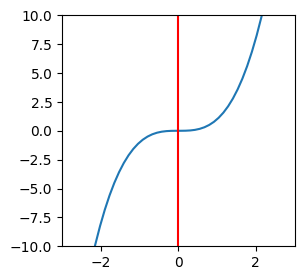

In [3]:
# Ejemplo inflexión
f = lambda x: x**3
x = np.linspace(-3, 3)
plt.figure(figsize=(3,3))
plt.plot(x, f(x))
plt.xlim(-3,3)
plt.ylim(-10,10)
plt.plot([0,0], [-10,10], color="red")
plt.show()

¿Qué pasa en 0?, también tenemos conceptos de maximos y minimos local y global, además en los polinomios a veces las  soluciones (raices) son complejas, que es otro problema. Recordar $\sqrt{b^2 - 4ac}$ cuando lo de adentro da negativo.

Recordar que mencionamos en metodos numéricos, que a veces el algoritmo queda "atrapado" en un maximo o minimo local, en el metodo de la gradiente descendente.

En multivariable pasa exactamente lo mismo, solo que el punto de inflexión lo llamamos punto de silla o **saddle point**.

Ejemplo tipico saddle point $ f(x,y) = x^2 - y^2 $

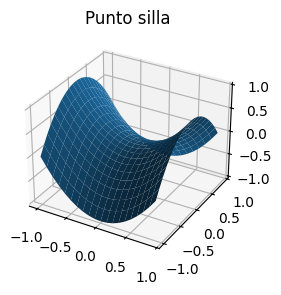

In [4]:
# Ejemplo saddle point
fig = plt.figure(figsize=(3,3))
ax = fig.add_subplot(projection='3d')
x, y = np.mgrid[-1:1:0.1,-1:1:0.1]
z = x**2 - y**2
ax.view_init(azim=-60, elev=30)
ax.plot_surface(x,y,z)
plt.title("Punto silla")
plt.show()

### Equivalencia entre maximos y minimos

Fijese que a veces queremos minimizar, por ejemplo el tiempo de viaje, o bien queremos maximizar, por ejemplo nuestra sabiduria que tenemos al estudiar este curso. Ambos, son equivalentes, pues:

$$ max f(x) = - min -f(x) $$

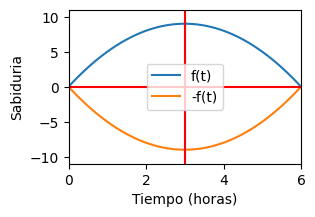

In [5]:
f_obj = lambda t: -t**2 + 6*t
t = np.linspace(0, 6)
plt.figure(figsize=(3,2))
plt.plot(t, f_obj(t), label="f(t)")
plt.plot(t, -f_obj(t), label="-f(t)")
plt.plot([-5,10], [0,0], color="red")
plt.plot([3,3], [-50,11], color="red")
plt.xlim(0,6)
plt.ylim(-11,11)
plt.xlabel("Tiempo (horas)")
plt.ylabel("Sabiduria")
plt.legend()
plt.show()

La literatura en optimización habla siempre de minimización, de hecho la curva azul es convexa (se relaciona a maximizar), en cambio la naranja es concava (se relaciona con minimizar), busquemos "optimización concava y convexa" en google y veamos.

### Restricciones

Ya vimos que no tiene sentido, tiempo negativo, elegir algun cafe que no existe en Chile, poner como alternativas para venir a la universidad lineas aereas, ó evaluar estudiar en una universidad extranjera (al menos para mi, no lo hice).

En nuestro modelo nosotros debemos declarar estas restricciones que reducen el **espacio de decisión**, ellas son restricciones de desigualdad e igualdad.

#### Restricciones de desigualdad

Se refiere a inecuaciones, como por ejemplo que el tiempo (horas) no puede ser negativo, entonces si nuestro tiempo de estudio es $t$ y nuestro certamen es mañana, podemos decir que:

$$ t >= 0 $$
$$ t < 24 $$

Fijese que no puede ser 24, pues llegariamos atrasados a la evaluación. Estas restricciones regularmente en el pensamiento computacional se complementan (representa un **and**), pues nos define un intervalo $[0,24[$.

#### Restricciones de igualdad

Son ecuaciones con las alternativas factibles o a evaluar, por lo que se suplementan (representa un **or**), por ejemplo si nosotros estudiamos en una sala reservada, la reserva dura 1 hora, por lo que podriamos decir que vamos a estudiar 2, 3 ó 4 horas. Son mas compactas, las podemos escribir asi:

$$ r_1(t) = t-2$$
$$ r_2(t) = t-3$$
$$ r_3(t) = t-4$$

$$ r_i(t) = 0 , \hspace{2cm} i=1,2,3 $$
